In [15]:
## Experiment 1 — Non-Maximum Suppression (NMS)

# Detection Analysis

This notebook analyzes important components of the object detection
post-processing pipeline.

## Objectives

- Understand Intersection over Union (IoU)
- Understand Non-Maximum Suppression (NMS)
- Compare class-aware and class-agnostic suppression
- Inspect how these concepts relate to real YOLO detections

This notebook is part of the
**Real-Time Object Detection & Tracking** project.

## 1. Intersection over Union (IoU)

IoU measures the overlap between two bounding boxes.

\[
IoU = \frac{Area(A \cap B)}{Area(A \cup B)}
\]

IoU ranges from 0 to 1:

- 0 → no overlap
- 1 → identical boxes

IoU is later used by NMS to determine whether two detections
overlap enough to be considered redundant.

In [32]:
def calculate_iou(box_a, box_b):
    """
    Calculate Intersection over Union (IoU)
    between two bounding boxes.

    Box format:
    [x1, y1, x2, y2]
    """

    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])

    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)

    intersection_area = (
        intersection_width * intersection_height
    )

    area_a = (
        (box_a[2] - box_a[0]) *
        (box_a[3] - box_a[1])
    )

    area_b = (
        (box_b[2] - box_b[0]) *
        (box_b[3] - box_b[1])
    )

    union_area = area_a + area_b - intersection_area

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

In [33]:
box_a = [10, 10, 50, 50]
box_b = [30, 30, 70, 70]

iou = calculate_iou(box_a, box_b)

print(f"IoU: {iou:.4f}")

IoU: 0.1429


## 2. Non-Maximum Suppression (NMS)

Object detectors can produce multiple overlapping predictions
for the same object.

NMS keeps the highest-confidence prediction and suppresses
redundant predictions with high IoU.

Basic procedure:

1. Select the detection with the highest confidence.
2. Compare it with the remaining detections.
3. Suppress detections whose IoU exceeds the threshold.
4. Repeat until no detections remain.

In [34]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    Basic Non-Maximum Suppression.

    Returns indices of the detections that are kept.
    """

    order = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True
    )

    keep = []

    while order:
        current = order.pop(0)
        keep.append(current)

        remaining = []

        for i in order:
            iou = calculate_iou(
                boxes[current],
                boxes[i]
            )

            if iou <= iou_threshold:
                remaining.append(i)

        order = remaining

    return keep

### Experiment 1 — Overlapping Predictions

We simulate three detections.

A and B strongly overlap and may represent duplicate
predictions for the same object.

C is spatially separate.

In [35]:
boxes = [
    [10, 10, 50, 50],    # A
    [12, 12, 48, 48],    # B
    [70, 70, 100, 100],  # C
]

scores = [
    0.95,
    0.82,
    0.60
]

print("IoU(A, B):", calculate_iou(boxes[0], boxes[1]))
print("IoU(A, C):", calculate_iou(boxes[0], boxes[2]))
print("IoU(B, C):", calculate_iou(boxes[1], boxes[2]))

IoU(A, B): 0.81
IoU(A, C): 0.0
IoU(B, C): 0.0


In [36]:
keep = nms(
    boxes,
    scores,
    iou_threshold=0.5
)

print("Kept detections:", keep)

Kept detections: [0, 2]


### Observation

The highest-confidence detection is kept first.

If another detection has sufficiently high IoU with it,
that detection is suppressed as a redundant prediction.

The IoU threshold therefore controls how aggressively
overlapping detections are removed.

## 3. Class-Aware NMS

The previous NMS implementation ignores object classes.

In object detection, two highly overlapping detections can
belong to different classes.

For example:

- Person
- Bicycle

A class-aware NMS processes detections independently by class,
so a detection from one class does not suppress a detection
from another class.

In [37]:
def nms_class_aware(boxes, scores, classes, iou_threshold=0.5):
    """
    Class-aware Non-Maximum Suppression.

    Detections belonging to different classes
    do not suppress each other.
    """

    order = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True
    )

    keep = []

    while order:
        current = order.pop(0)
        keep.append(current)

        remaining = []

        for i in order:

            # Different classes do not suppress each other
            if classes[current] != classes[i]:
                remaining.append(i)
                continue

            iou = calculate_iou(
                boxes[current],
                boxes[i]
            )

            if iou <= iou_threshold:
                remaining.append(i)

        order = remaining

    return keep

## 4. Experiment 2 — Two Nearby Persons

A limitation of NMS appears when two different objects
of the same class are very close to each other.

Both detections may have a high IoU even though they
represent two different real-world objects.

In [38]:
boxes = [
    [10, 10, 60, 100],  # Person A
    [30, 10, 80, 100],  # Person B
]

scores = [
    0.95,
    0.85
]

classes = [
    0,  # person
    0   # person
]

print("IoU:", calculate_iou(boxes[0], boxes[1]))

keep = nms_class_aware(
    boxes,
    scores,
    classes,
    iou_threshold=0.5
)

print("Kept detections:", keep)

IoU: 0.42857142857142855
Kept detections: [0, 1]


### Observation

Both detections belong to the `person` class.

Therefore, class-aware NMS does not distinguish them as
different objects.

If their IoU exceeds the suppression threshold, one
detection may be removed even though both persons are real.

This shows that NMS alone cannot maintain object identity.

In [39]:
classes = [
    0,  # person
    2   # car
]

keep = nms_class_aware(
    boxes,
    scores,
    classes,
    iou_threshold=0.5
)

print("Kept detections:", keep)

Kept detections: [0, 1]


### Observation

The two detections have different classes.

Therefore, one class does not suppress the other in
class-aware NMS, even when their bounding boxes overlap.

This is an important difference between class-aware and
class-agnostic suppression.

## 5. Inspecting Real YOLO Detections

The previous experiments used synthetic bounding boxes
to isolate the behavior of IoU and NMS.

Now we inspect detections produced by the YOLO model
used in the project.

In [40]:
!pip install -q ultralytics

In [41]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [43]:
from ultralytics.utils.downloads import download

download(
    "https://ultralytics.com/images/bus.jpg",
    dir="."
)

In [44]:
results = model("bus.jpg")

result = results[0]

print("Number of detections:", len(result.boxes))

for i, box in enumerate(result.boxes):
    class_id = int(box.cls)
    class_name = model.names[class_id]
    confidence = float(box.conf)
    coordinates = box.xyxy.tolist()[0]

    print(f"\nDetection {i}")
    print("Class:", class_name)
    print("Confidence:", f"{confidence:.4f}")
    print("Bounding box:", coordinates)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 333.9ms
Speed: 27.5ms preprocess, 333.9ms inference, 33.1ms postprocess per image at shape (1, 3, 640, 480)
Number of detections: 5

Detection 0
Class: bus
Confidence: 0.9402
Bounding box: [3.8327178955078125, 229.36427307128906, 796.194580078125, 728.4122924804688]

Detection 1
Class: person
Confidence: 0.8882
Bounding box: [671.0172119140625, 394.83319091796875, 809.8097534179688, 878.7124633789062]

Detection 2
Class: person
Confidence: 0.8783
Bounding box: [47.404701232910156, 399.5651550292969, 239.3006591796875, 904.1949462890625]

Detection 3
Class: person
Confidence: 0.8558
Bounding box: [223.0589599609375, 408.68865966796875, 344.4676513671875, 860.435791015625]

Detection 4
Class: person
Confidence: 0.6219
Bounding box: [0.021725893020629883, 556.0684204101562, 68.88552856445312, 872.3591918945312]


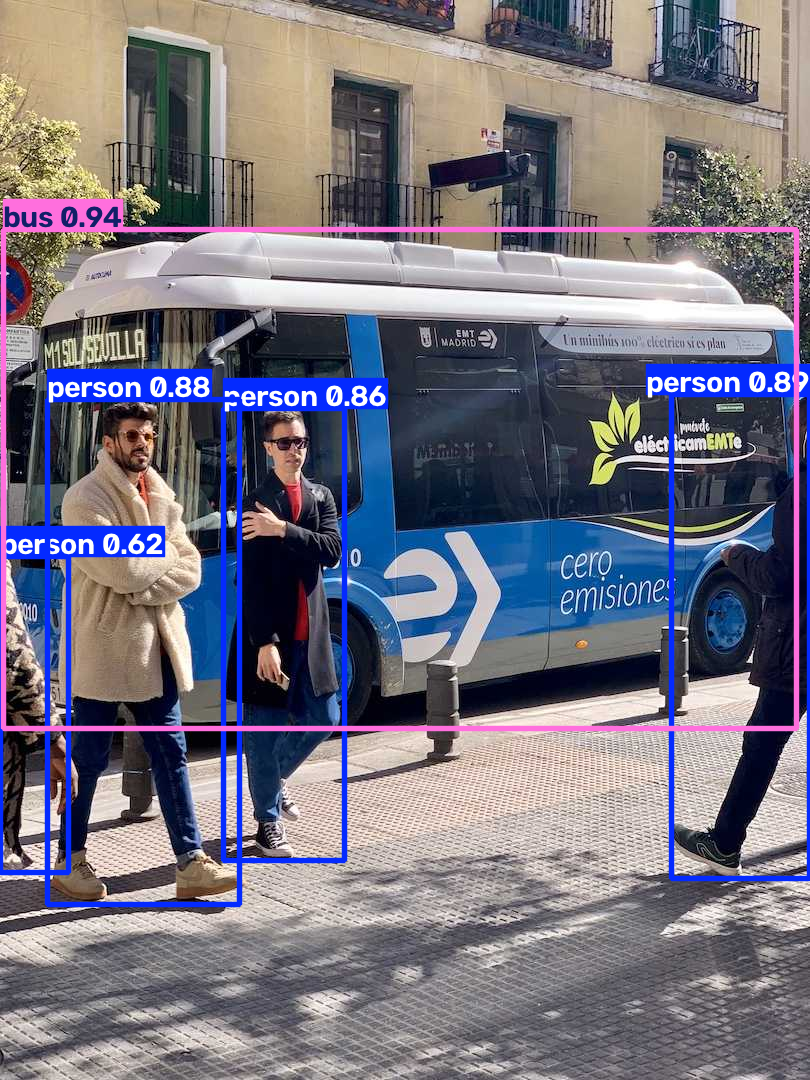

In [45]:
result.show()

## 6. Findings

### IoU

IoU measures the spatial overlap between two bounding boxes
and provides the basis for overlap-based suppression.

### NMS

NMS reduces redundant detections by keeping higher-confidence
predictions and suppressing highly overlapping predictions.

### Class-Aware NMS

Detections from different classes are processed independently,
so overlapping objects from different classes can both be retained.

### Limitation

Class-aware NMS cannot determine whether two overlapping
detections of the same class represent one object or multiple
real objects.

For example, two nearby persons may have highly overlapping
bounding boxes and one detection may be suppressed.

### Implication for the Project

NMS solves duplicate detection at the detection stage,
but it does not provide object identity across video frames.

This motivates the next stage of the project:

**Object Tracking**